In [ ]:
# compute_stats.py
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF

DATA_ROOT_TRAIN_INDUSTRIAL = "dataset/train"  # 👈 change if needed
BATCH_SIZE = 32

def get_transform_no_norm():
    """Same preprocessing as training, but WITHOUT Normalize."""
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.Lambda(lambda x: TF.adjust_gamma(x, gamma=1.45, gain=1)),
        transforms.ToTensor(),
    ])

def compute_mean_std(root_dir):
    dataset = datasets.ImageFolder(root=root_dir, transform=get_transform_no_norm())
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    n_channels = 3
    sum_ = torch.zeros(n_channels)
    sum_sq = torch.zeros(n_channels)
    num_pixels = 0

    for images, _ in loader:
        # images: [B, C, H, W]
        B, C, H, W = images.shape
        pixels_in_batch = B * H * W
        num_pixels += pixels_in_batch

        sum_ += images.sum(dim=[0, 2, 3])
        sum_sq += (images ** 2).sum(dim=[0, 2, 3])

    mean = sum_ / num_pixels
    var = (sum_sq / num_pixels) - (mean ** 2)
    std = torch.sqrt(var)

    return mean, std

if __name__ == "__main__":
    mean, std = compute_mean_std(DATA_ROOT_TRAIN_INDUSTRIAL)
    print("TRAIN mean:", mean)
    print("TRAIN std :", std)


In [ ]:
# train_crack_classifier.py
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF
from tqdm import tqdm

# =========================
# CONFIG
# =========================
DATA_ROOT_TRAIN_INDUSTRIAL = "dataset/original/train"   #  path to industrial train
DATA_ROOT_TRAIN_CONCRETE   = "dataset/open-source/train"     # path to concrete train (optional)
DATA_ROOT_VAL_CHALLENGE    = "dataset/val"      # path to challenge validation

USE_CONCRETE_AUG = True     # set False to train ONLY on industrial
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_CLASSES = 2             # defect / no_defect

#  Put the TRAIN mean/std you got from compute_stats.py here
TRAIN_MEAN = [0.5061, 0.5061, 0.5061]
TRAIN_STD  = [0.2324, 0.2324, 0.2324]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# TRANSFORMS
# =========================
import random

def metal_surface_augmentation(img):
    # Add Gaussian noise
    img = img + 0.03 * torch.randn_like(img)

    # Apply blur
    img = TF.gaussian_blur(img, kernel_size=5, sigma=random.uniform(0.1, 2.0))

    # Add random lighting gradient
    h, w = img.shape[1], img.shape[2]
    gradient = torch.linspace(0, random.uniform(0.3,0.7), steps=h).unsqueeze(1).expand(-1, w)
    gradient = gradient.unsqueeze(0)
    img = img * gradient

    return img

def get_train_transform():
    """
    Train transform:
      - Grayscale -> 3 channels
      - Resize
      - Mild photometric augmentation
      - Gamma correction
      - Normalize with TRAIN stats
    """
def get_train_transform():
    return transforms.Compose([
        transforms.Grayscale(3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(metal_surface_augmentation),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
    ])



def get_val_transform():
    """
    Validation / challenge transform:
      - SAME preprocessing as train, but NO random augmentation.
    """
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        # transforms.Lambda(lambda x: TF.adjust_gamma(x, gamma=1.1, gain=1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
    ])

# =========================
# DATASETS & LOADERS
# =========================
def build_dataloaders():
    train_tf = get_train_transform()
    val_tf = get_val_transform()

    # Industrial training dataset (MAIN)
    ds_train_industrial = datasets.ImageFolder(
        root=DATA_ROOT_TRAIN_INDUSTRIAL,
        transform=train_tf,
    )

    train_datasets = [ds_train_industrial]

    # Optional concrete dataset for augmentation
    if USE_CONCRETE_AUG and os.path.isdir(DATA_ROOT_TRAIN_CONCRETE):
        ds_train_concrete = datasets.ImageFolder(
            root=DATA_ROOT_TRAIN_CONCRETE,
            transform=train_tf,
        )
        train_datasets.append(ds_train_concrete)
        print(f"[INFO] Using concrete augmentation dataset with {len(ds_train_concrete)} images.")
    else:
        print("[INFO] NOT using concrete augmentation dataset.")

    # Merge all train datasets
    if len(train_datasets) > 1:
        train_dataset = ConcatDataset(train_datasets)
    else:
        train_dataset = train_datasets[0]

    print(f"[INFO] Total train images: {len(train_dataset)}")

    # Challenge validation dataset
    val_dataset = datasets.ImageFolder(
        root=DATA_ROOT_VAL_CHALLENGE,
        transform=val_tf,
    )
    print(val_dataset.classes)
    print(f"[INFO] Challenge val images: {len(val_dataset)}")

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    return train_loader, val_loader

# =========================
# MODEL
# =========================
def build_model_resnet_18(num_classes=NUM_CLASSES):
    """
    Simple ResNet-18 backbone.
    You can change to EfficientNet if you want.
    """
    model = models.resnet18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def build_model_resnet34(num_classes=NUM_CLASSES):
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_model_mobilenet_v3_large(num_classes=NUM_CLASSES):
    model = models.mobilenet_v3_large(
        weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
    )
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

def build_model_efficientnet_b0(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


# =========================
# TRAIN & EVAL LOOPS
# =========================
def train_one_epoch(model, loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", unit="batch")
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)         # [B, num_classes]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100.0 * correct / total:.2f}%"
        })

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, epoch, split_name="Val"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc=f"{split_name} Epoch {epoch}", unit="batch"):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# =========================
# MAIN
# =========================
def main():
    print(f"[INFO] Using device: {DEVICE}")
    train_loader, val_loader = build_dataloaders()

    model = build_model_resnet34(NUM_CLASSES).to(DEVICE)
    # model = build_model(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_val_acc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
        val_loss, val_acc = evaluate(model, val_loader, criterion, epoch, split_name="Val")

        print(f"Epoch {epoch:02d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model on challenge val
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            os.makedirs("runs", exist_ok=True)
            ckpt_path = os.path.join("runs", "best_model.pth")
            torch.save(model.state_dict(), ckpt_path)
            print(f"[INFO] New best val acc: {best_val_acc:.2f}% -> saved to {ckpt_path}")

    print(f"[DONE] Best challenge val accuracy: {best_val_acc:.2f}%")

if __name__ == "__main__":
    main()


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
print(f"[INFO] Using device: {DEVICE}")
train_loader, val_loader = build_dataloaders()
imgs, labels = next(iter(val_loader))
img = imgs[0].permute(1,2,0).cpu().numpy()

plt.imshow((img * TRAIN_STD + TRAIN_MEAN).clip(0,1))
plt.title(labels[0].item())
plt.show()


[INFO] Using device: cuda
[VAL STATS] mean=0.4168, std=0.2367


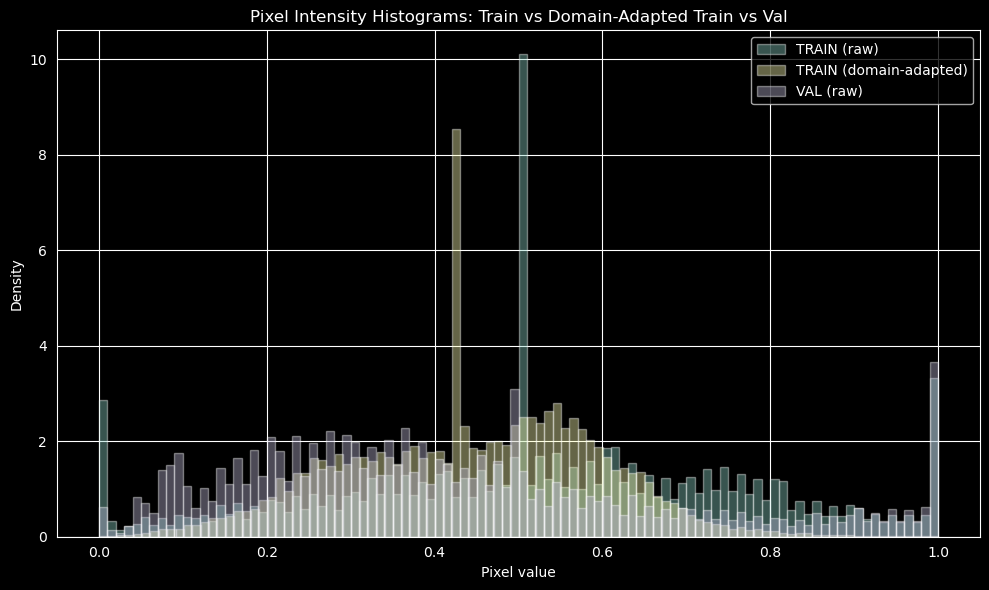

[RAW TRAIN] mean=0.5274, std=0.2430
[ADAPTED TRAIN] mean=0.4445, std=0.1482
[RAW VAL] mean=0.4221, std=0.2534


Val   Epoch 1: 100%|██████████| 212/212 [00:03<00:00, 61.33batch/s]


Epoch 01 | Train Loss: 0.3807 | Train Acc: 69.28% | Val Loss: 0.7223 | Val Acc: 59.51%
[INFO] New best val acc: 59.51% → saved to runs/best_model_domain_adapted.pth


Val   Epoch 2: 100%|██████████| 212/212 [00:03<00:00, 63.06batch/s]


Epoch 02 | Train Loss: 0.3151 | Train Acc: 72.29% | Val Loss: 0.6523 | Val Acc: 65.14%
[INFO] New best val acc: 65.14% → saved to runs/best_model_domain_adapted.pth


...

Epoch 23 | Train Loss: 0.1920 | Train Acc: 76.08% | Val Loss: 0.9078 | Val Acc: 59.44%


Val   Epoch 24: 100%|██████████| 212/212 [00:03<00:00, 62.06batch/s]


Epoch 24 | Train Loss: 0.1805 | Train Acc: 77.00% | Val Loss: 0.8590 | Val Acc: 61.82%


Val   Epoch 25: 100%|██████████| 212/212 [00:03<00:00, 61.61batch/s]

Epoch 25 | Train Loss: 0.1869 | Train Acc: 77.20% | Val Loss: 1.0411 | Val Acc: 59.49%
[DONE] Best Val Accuracy: 65.14%


In [2]:
import os
import random
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================
# CONFIG
# =========================

def crack_soften(img):
    # decreasing contrast of possible crack strokes
    if random.random() < 0.6:
        blur_sigma = random.uniform(1.0, 3.0)
        img = TF.gaussian_blur(img, kernel_size=9, sigma=blur_sigma)
    return img

def metal_texture(img):
    if random.random() < 0.7:
        # sinusoidal illumination noise
        C, H, W = img.shape
        x = torch.linspace(0, np.pi * random.uniform(1,3), steps=W)
        illumination = (torch.sin(x) * 0.1).expand(H, W)
        illumination = illumination.unsqueeze(0).expand(C, H, W)
        img = img + illumination
    return img.clamp(0,1)

def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

DATA_ROOT_TRAIN = "dataset/filtered/train"
DATA_ROOT_VAL   = "dataset/val"

BATCH_SIZE   = 32
NUM_WORKERS  = 4
NUM_EPOCHS   = 25
LR           = 5e-5
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# BASIC TRANSFORMS (NO NORMALIZE)
# =========================
def get_base_transform():
    # raw grayscale tensor in [0,1], resized
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])


# =========================
# 1) COMPUTE VAL DISTRIBUTION (TARGET DOMAIN)
# =========================
def compute_val_distribution(val_dataset, n_samples=200):
    loader = DataLoader(val_dataset, batch_size=32, shuffle=True,
                        num_workers=NUM_WORKERS)
    means, stds = [], []

    seen = 0
    for imgs, _ in loader:
        imgs = imgs  # [B,C,H,W] in [0,1]
        means.append(imgs.mean().item())
        stds.append(imgs.std().item())
        seen += imgs.size(0)
        if seen >= n_samples:
            break

    val_mean = float(np.mean(means))
    val_std  = float(np.mean(stds))
    print(f"[VAL STATS] mean={val_mean:.4f}, std={val_std:.4f}")
    return {"mean": val_mean, "std": val_std}


# =========================
# DOMAIN ADAPTATION HELPERS
# =========================
def match_histogram_style(src, tgt_mean, tgt_std):
    """
    Shift src image (tensor [C,H,W] in [0,1]) to match target mean/std.
    """
    src_mean = src.mean()
    src_std  = src.std()
    if src_std < 1e-6:
        src_std = 1e-6

    out = (src - src_mean) / src_std      # zero-mean, unit-var
    out = out * tgt_std + tgt_mean        # match target stats
    out = torch.sigmoid((out - 0.5) * 3)  # smooth compress to [0,1]
    return out


def metal_surface_augment(img):
    """
    Extra texture/illumination augmentation AFTER domain match.
    img in [0,1]
    """
    # noise
    if random.random() < 0.7:
        noise_std = random.uniform(0.01, 0.04)
        img = img + noise_std * torch.randn_like(img)

    # small blur
    if random.random() < 0.7:
        sigma = random.uniform(0.1, 1.0)
        img = TF.gaussian_blur(img, kernel_size=5, sigma=sigma)

    # tiny rotation jitter
    # (need to convert to PIL for TF.rotate; easier to skip here since resize done)
    img = torch.clamp(img, 0.0, 1.0)
    return img


class DomainAdaptiveDataset(Dataset):
    """
    Wraps an ImageFolder and:
      - applies base_transform (PIL -> tensor)
      - matches TRAIN image brightness/contrast to VAL distribution
      - applies optional augmentation
      - normalizes with VAL stats (same for train+val)
    """
    def __init__(self, image_folder, val_stats, base_transform, do_augment=True):
        self.ds = image_folder
        self.val_mean = val_stats["mean"]
        self.val_std  = val_stats["std"]
        self.base_tf  = base_transform
        self.do_augment = do_augment

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]       # PIL

        # 1) Base transform -> grayscale & resize -> tensor in [0,1]
        img = self.base_tf(img)

        # 2) Domain adaptation (TRAIN → VAL alignment)
        img = match_histogram_style(img, self.val_mean, self.val_std)

        # 3) Structural + metal surface augmentations (TRAIN ONLY)
        if self.do_augment:
            img = crack_soften(img)     # soften crack edges
            img = metal_texture(img)    # ADD METAL TEXTURE HERE ✔️

        # 4) Final normalization (use VAL stats, same for train & val)
        img = (img - self.val_mean) / (self.val_std + 1e-6)

        return img, label


# =========================
# 2) BUILD LOADERS (DOMAIN-ADAPTIVE)
# =========================
def build_dataloaders():
    base_tf = get_base_transform()

    # raw (unnormalized) datasets for stats & visualization
    train_raw = datasets.ImageFolder(DATA_ROOT_TRAIN, transform=base_tf)
    val_raw   = datasets.ImageFolder(DATA_ROOT_VAL,   transform=base_tf)

    # compute VAL distribution (target)
    val_stats = compute_val_distribution(val_raw)

    # domain-adaptive train dataset
    train_da = DomainAdaptiveDataset(
        datasets.ImageFolder(DATA_ROOT_TRAIN),  # no transform here
        val_stats=val_stats,
        base_transform=base_tf,
        do_augment=True,
    )

    # validation dataset: domain-matched, but no extra aug
    val_da = DomainAdaptiveDataset(
        datasets.ImageFolder(DATA_ROOT_VAL),
        val_stats=val_stats,
        base_transform=base_tf,
        do_augment=False,
    )

    train_loader = DataLoader(train_da, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_da, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    # also return raw datasets for histogram plotting
    return train_loader, val_loader, train_raw, val_raw, val_stats


# =========================
# 4) HISTOGRAM VISUALIZATION
# =========================
def plot_histograms(train_raw, val_raw, val_stats, n_samples=300):
    """
    Show histograms of:
      - original TRAIN pixels
      - TRAIN after domain adaptation
      - VAL pixels
    """
    base_tf = get_base_transform()
    tr_loader = DataLoader(train_raw, batch_size=32, shuffle=True,
                           num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_raw, batch_size=32, shuffle=True,
                            num_workers=NUM_WORKERS)

    train_pix = []
    train_da_pix = []
    val_pix = []

    # collect some TRAIN pixels
    seen = 0
    for imgs, _ in tr_loader:
        imgs = imgs  # already base_tf → [0,1]
        train_pix.append(imgs.flatten().numpy())

        # domain-adapted version
        for i in range(imgs.size(0)):
            da = match_histogram_style(imgs[i], val_stats["mean"], val_stats["std"])
            train_da_pix.append(da.flatten().numpy())

        seen += imgs.size(0)
        if seen >= n_samples:
            break

    # collect some VAL pixels
    seen = 0
    for imgs, _ in val_loader:
        val_pix.append(imgs.flatten().numpy())
        seen += imgs.size(0)
        if seen >= n_samples:
            break

    train_pix    = np.concatenate(train_pix)
    train_da_pix = np.concatenate(train_da_pix)
    val_pix      = np.concatenate(val_pix)

    plt.figure(figsize=(10, 6))
    plt.hist(train_pix,    bins=100, alpha=0.4, density=True, label="TRAIN (raw)")
    plt.hist(train_da_pix, bins=100, alpha=0.4, density=True, label="TRAIN (domain-adapted)")
    plt.hist(val_pix,      bins=100, alpha=0.4, density=True, label="VAL (raw)")
    plt.xlabel("Pixel value")
    plt.ylabel("Density")
    plt.title("Pixel Intensity Histograms: Train vs Domain-Adapted Train vs Val")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"[RAW TRAIN] mean={train_pix.mean():.4f}, std={train_pix.std():.4f}")
    print(f"[ADAPTED TRAIN] mean={train_da_pix.mean():.4f}, std={train_da_pix.std():.4f}")
    print(f"[RAW VAL] mean={val_pix.mean():.4f}, std={val_pix.std():.4f}")


# =========================
# MODEL + TRAINING
# =========================
# =========================
# MODEL
# =========================
def build_model_resnet_18(num_classes=NUM_CLASSES):
    """
    Simple ResNet-18 backbone.
    You can change to EfficientNet if you want.
    """
    model = models.resnet18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def build_model_resnet34(num_classes=NUM_CLASSES):
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_model_mobilenet_v3_large(num_classes=NUM_CLASSES):
    model = models.mobilenet_v3_large(
        weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
    )
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

def build_model_efficientnet_b0(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

import torch
import numpy as np

def mixup_data(x, y, alpha=0.3):
    """
    Returns mixed inputs, paired targets, and mixing coefficient.
    """
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def train_one_epoch(model, loader, criterion, optimizer, epoch, mixup_alpha=0.3):
    """
    Train loop with MixUp support.
    """
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", unit="batch")

    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # -----------------------------
        # MIXUP
        # -----------------------------
        imgs, targets_a, targets_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)

        optimizer.zero_grad()

        # forward pass
        outputs = model(imgs)

        # MixUp loss = lam*L(a) + (1-lam)*L(b)
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

        loss.backward()
        optimizer.step()

        # -----------------------------
        # Compute running accuracy
        # We evaluate accuracy using the dominant label (argmax of one-hot mix)
        # This underestimates accuracy but is ok for monitoring.
        # -----------------------------
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()  # original labels
        total += labels.size(0)

        running_loss += loss.item() * imgs.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{100.0 * correct / max(total, 1):.2f}%"
        })

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, epoch):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.inference_mode():
        pbar = tqdm(loader, desc=f"Val   Epoch {epoch}", unit="batch")
        for imgs, labels in pbar:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            out = model(imgs)
            loss = criterion(out, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, 100.0 * correct / total


# =========================
# MAIN
# =========================
def main():
    print(f"[INFO] Using device: {DEVICE}")

    train_loader, val_loader, train_raw, val_raw, val_stats = build_dataloaders()

    # 4) visualize histograms BEFORE training
    plot_histograms(train_raw, val_raw, val_stats)

    # model = build_model_resnet34().to(DEVICE)
    model =  build_model_efficientnet_b0(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_acc = 0.0
    os.makedirs("runs", exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
        val_loss, val_acc = evaluate(model, val_loader, criterion, epoch)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            ckpt = os.path.join("runs", "best_model_domain_adapted.pth")
            torch.save(model.state_dict(), ckpt)
            print(f"[INFO] New best val acc: {best_val_acc:.2f}% → saved to {ckpt}")

    print(f"[DONE] Best Val Accuracy: {best_val_acc:.2f}%")


if __name__ == "__main__":
    main()
